In [31]:
# ===== INSTALL PACKAGES =====
!pip install -q seaborn

# ===== IMPORTS =====
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import pandas as pd
import json
import zipfile
import os
import seaborn as sns
import random
import shutil
import time

from PIL import Image
from matplotlib import pyplot as plt

from keras.models import Sequential, Model

from tensorflow.keras.applications import InceptionV3, Xception, InceptionResNetV2, ResNet50
from tensorflow.keras.applications.resnet import preprocess_input

from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Output folders
!mkdir -p output
!mkdir -p output/tmp-augmented-images/

# Seeds
random.seed(123)
np.random.seed(123)
tf.random.set_seed(123)

# Disable wandb
USE_WANDB = False


In [32]:
# You need to insert your own API key below to run the code

kaggle = {
    "username": "<your-kaggle-username>",
    "api_key": "<your-kaggle-api-key>",
    "on_kernel": False,
    "dataset": {
        "sample": "-",
        "full": "paultimothymooney/chest-xray-pneumonia"
        }
}

if kaggle["on_kernel"]:
  path_prefix = '/kaggle/working/'
else:
  path_prefix = '/content/'

# Download dataset
def download_dataset(which_dataset):
  data = {"username": kaggle["username"],"key": kaggle["api_key"]}
  with open('kaggle.json', 'w') as json_file:
      json.dump(data, json_file)

  !mkdir -p ~/.kaggle
  !cp kaggle.json ~/.kaggle/
  !chmod 600 ~/.kaggle/kaggle.json
  kaggle_dataset = kaggle["dataset"][which_dataset]
  !kaggle datasets download -d $kaggle_dataset

  # Paths neeeds to be changed manually because of different directory structures, check with !ls
  if not os.path.isdir('dataset'):
    print("Unzipping... ")
    zip_ref = zipfile.ZipFile('chest-xray-pneumonia.zip', 'r')
    zip_ref.extractall('dataset')
    zip_ref.close()
    !rm -rf /content/dataset/chest_xray/chest_xray
    !rm -rf /content/dataset/chest_xray/__MACOSX
    !rm -rf /content/chest-xray-pneumonia.zip


  #!ls Data


download_dataset("full")

data_files = os.listdir("dataset/chest_xray")
print(data_files)

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
 99% 2.27G/2.29G [00:22<00:00, 317MB/s]
100% 2.29G/2.29G [00:22<00:00, 108MB/s]
['test', 'val', 'train']


In [33]:
!unzip -q /content/chest-xray-pneumonia.zip -d /content/


In [1]:
# Remove nested duplicate and Mac junk
!rm -rf /content/chest_xray/chest_xray
!rm -rf /content/chest_xray/__MACOSX

# Remove second duplicate dataset to avoid confusion
!rm -rf /content/dataset


In [34]:
!ls /content/

chest_xray  chest-xray-pneumonia.zip  dataset  kaggle.json  output  sample_data


In [35]:
!ls /content/dataset/chest_xray/


test  train  val


In [36]:
!ls /content/dataset/chest_xray/train/


NORMAL	PNEUMONIA


In [18]:
TRAIN_PATH = "/content/dataset/chest_xray/train"
TEST_PATH  = "/content/dataset/chest_xray/test"
VAL_PATH   = "/content/dataset/chest_xray/val"


In [37]:
def resample_data(move_from, move_to, cl, images_to_move=100):
  path = path_prefix + 'dataset/chest_xray/'

  classes = os.listdir(path + move_from)

  cl += '/'
  curr_path = path + move_from + cl
  for _, _, files in os.walk(curr_path):
    random.shuffle(files)
    files_to_move = files[:images_to_move]
    for fn in files_to_move:
      shutil.move(curr_path + fn, path + move_to + cl + fn)
      #print('Moved ' + curr_path + fn)

  print('Resampled Images')

move_from, move_to = 'train/', 'val/'
#resample_data(move_from, move_to, 'PNEUMONIA', 2534)



# Training images
print('Number of NORMAL training images:')
!ls /content/dataset/chest_xray/train/NORMAL/ | wc -l
print('Number of PNEUMONIA training images:')
!ls /content/dataset/chest_xray/train/PNEUMONIA/ | wc -l
print()


# Test images
#resample_data('test/', 'val/', 'PNEUMONIA', 2690)
print('Number of NORMAL test images:')
!ls /content/dataset/chest_xray/test/NORMAL/ | wc -l
print('Number of PNEUMONIA test images:')
!ls /content/dataset/chest_xray/test/PNEUMONIA/ | wc -l

Number of NORMAL training images:
1341
Number of PNEUMONIA training images:
3875

Number of NORMAL test images:
234
Number of PNEUMONIA test images:
390


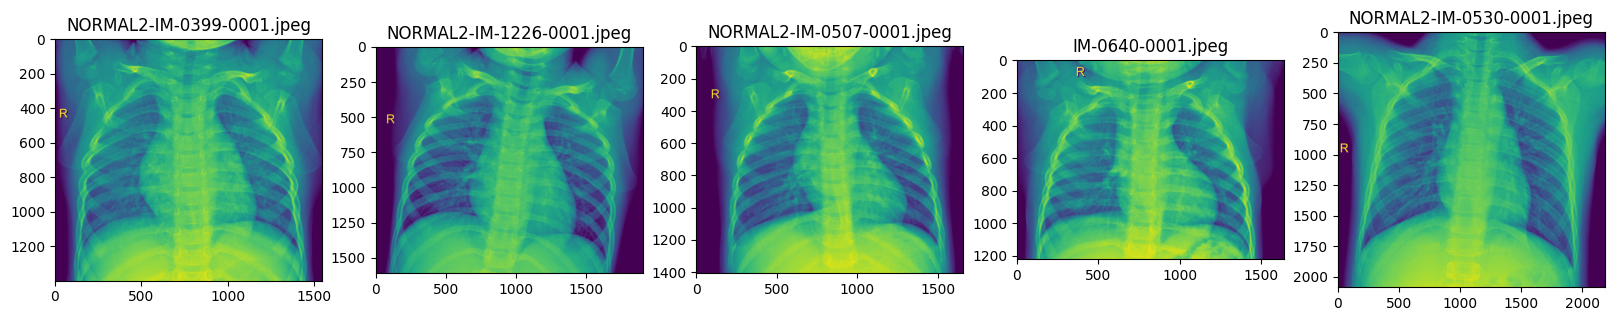

In [38]:
def viewImagesFromDir(path, num=5):
  #Display num random images from dataset. Rerun cell for new random images. The images are only single-channel

  img_paths_visualise = sorted(
        os.path.join(path, fname)
        for fname in os.listdir(path)
        if fname.endswith(".jpeg")
  )

  random.shuffle(img_paths_visualise)

  fig, ax = plt.subplots(1, num, figsize=(20, 10))

  for i in range(num):
    ax[i].imshow(Image.open(img_paths_visualise[i]))
    index = img_paths_visualise[i].rfind('/') + 1
    ax[i].title.set_text(img_paths_visualise[i][index:])

  fig.canvas.draw()
  time.sleep(1)

viewImagesFromDir('/content/dataset/chest_xray/train/NORMAL/', num=5)

In [39]:
CLASSES = os.listdir('/content/dataset/chest_xray/train')
TRAINING_DATA_SET_PATH = '/content/dataset/chest_xray/train'
TEST_DATA_SET_PATH = '/content/dataset/chest_xray/test'
VAL_PATH   = '/content/dataset/chest_xray/val'

params = dict(
    seed = 123,
    image_dim = (288,288),
    weight_decay = 1e-4,
    epochs = 30,
    batch_size = 16,
    patch_size = 18,
    pool_size = (2,2),
    optimizer = 'Adam',
    l_rate = 0.001,
    val_split = .15,
    use_transfer_learning = False,
    use_data_aug = False,

    l2_reg = .0,
    projection_dim = 16,
    num_heads = 4,

    # Size of the transformer layers
    transformer_layers = 4,
    num_classes = len(CLASSES),
    mlp_head_units = [1024,512]

    )

new_params = dict(
    num_patches = (params['image_dim'][0] // params['patch_size']) ** 2,
    transformer_units = [
    params['projection_dim'] * 2,
    params['projection_dim']],
    input_shape = (params['image_dim'][0], params['image_dim'][1], 3),

)
params.update(new_params)


if params['use_data_aug']:
  data_aug_params = dict(
      da_rotation = 20,
      da_w_shift = 0.1,
      da_h_shift = 0.1,
      da_shear = 0.05,
      da_zoom = 0.05,
      da_h_flip = False,
      da_v_flip = False,
  )

  params.update(data_aug_params)


# Ability to switch amount of channel to utilise pre-trained models with specific input shapes
if params['use_transfer_learning']:
  INPUT_SHAPE = (params['image_dim'][0], params['image_dim'][1], 3)
  COLOUR_MODE = 'rgb'
else:
  INPUT_SHAPE = (params['image_dim'][0], params['image_dim'][1], 3)
  COLOUR_MODE = 'rgb'

if params['use_data_aug']:
  datagen = ImageDataGenerator(validation_split=params['val_split'], rescale=1./255,
                               rotation_range=params['da_rotation'],
                               width_shift_range=params['da_w_shift'],
                               height_shift_range=params['da_h_shift'],
                               shear_range=params['da_shear'],
                               zoom_range=params['da_zoom'],
                               horizontal_flip=params['da_h_flip'],
                               vertical_flip=params['da_v_flip'],
                               fill_mode="constant",
                               cval=0
                               )
else:
  datagen = ImageDataGenerator(validation_split=params['val_split'])

# Read all training and validation data into variables from directory.
# Due to faulty quality of the given validation-set images, all images are taken from the training folder
train_generator = datagen.flow_from_directory(TRAINING_DATA_SET_PATH,
                                                    batch_size=params['batch_size'],
                                                    seed=123,
                                                    class_mode="categorical",
                                                    classes=CLASSES,
                                                    target_size=params['image_dim'],
                                                    color_mode=COLOUR_MODE,
                                                    subset='training',
                                                    shuffle=True)

val_datagen = ImageDataGenerator(validation_split=0.15, rescale=1./255)
valid_generator = datagen.flow_from_directory(TRAINING_DATA_SET_PATH,
                                                    batch_size=params['batch_size'],
                                                    seed=123,
                                                    class_mode="categorical",
                                                    classes=CLASSES,
                                                    target_size=params['image_dim'],
                                                    color_mode=COLOUR_MODE,
                                                    subset='validation',
                                                    shuffle=False)

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(TEST_DATA_SET_PATH,
                                                    batch_size=params['batch_size'],
                                                    seed=123,
                                                    class_mode="categorical",
                                                    classes=CLASSES,
                                                    target_size=params['image_dim'],
                                                    color_mode=COLOUR_MODE,
                                                    shuffle=False)


Found 4434 images belonging to 2 classes.
Found 782 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [40]:
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

class Patches(layers.Layer):
    def __init__(self, patch_size):
        super(Patches, self).__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches


# Linearly transform patches by projecting it into a
# vector of size `projection_dim` and also adds a learnable position
# embedding to the projected vector.
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super(PatchEncoder, self).__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded

Image size: 288 X 288
Patch size: 18 X 18
Patches per image: 256
Elements per patch: 972


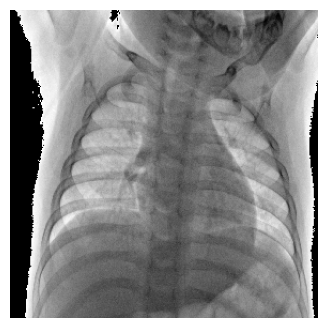

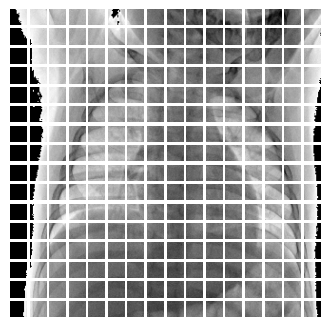

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 4))
image, label = iter(next(train_generator))
image = image[0]*255.
#image = x_train[np.random.choice(range(x_train.shape[0]))]
plt.imshow((image).astype("uint8"))
plt.axis("off")

resized_image = tf.image.resize(
    tf.convert_to_tensor([image]), size=(params['image_dim'][0], params['image_dim'][0])
)
patches = Patches(params['patch_size'])(resized_image)
print(f"Image size: {params['image_dim'][0]} X {params['image_dim'][0]}")
print(f"Patch size: {params['patch_size']} X {params['patch_size']}")
print(f"Patches per image: {patches.shape[1]}")
print(f"Elements per patch: {patches.shape[-1]}")

n = int(np.sqrt(patches.shape[1]))
plt.figure(figsize=(4, 4))
for i, patch in enumerate(patches[0]):
    ax = plt.subplot(n, n, i + 1)
    patch_img = tf.reshape(patch, (params['patch_size'], params['patch_size'], 3))
    plt.imshow(patch_img.numpy().astype("uint8"))
    plt.axis("off")

In [42]:
num_classes = len(CLASSES)
num_patches = (params["image_dim"][0] // params["patch_size"])**2
input_shape = (*params["image_dim"], 3)

class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1,self.patch_size,self.patch_size,1],
            strides=[1,self.patch_size,self.patch_size,1],
            rates=[1,1,1,1],
            padding="VALID"
        )
        return tf.reshape(patches, [tf.shape(images)[0], -1, patches.shape[-1]])

class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.projection = layers.Dense(projection_dim)
        self.position = layers.Embedding(num_patches, projection_dim)

    def call(self, patches):
        positions = tf.range(start=0, limit=num_patches, delta=1)
        return self.projection(patches) + self.position(positions)

def mlp(x, hidden_units):
    for units in hidden_units:
        x = layers.Dense(units, activation="gelu")(x)
        x = layers.Dropout(0.1)(x)
    return x

def create_vit():
    inputs = layers.Input(shape=input_shape)
    patches = Patches(params["patch_size"])(inputs)
    x = PatchEncoder(num_patches, params["projection_dim"])(patches)

    for _ in range(params["transformer_layers"]):
        y = layers.LayerNormalization()(x)
        y = layers.MultiHeadAttention(num_heads=params["num_heads"], key_dim=params["projection_dim"])(y, y)
        x = layers.Add()([x, y])

        y = layers.LayerNormalization()(x)
        y = mlp(y, [params["projection_dim"]*2, params["projection_dim"]])
        x = layers.Add()([x, y])

    x = layers.LayerNormalization()(x)
    x = layers.Flatten()(x)
    x = mlp(x, params["mlp_head_units"])
    outputs = layers.Dense(num_classes)(x)  # logits

    return keras.Model(inputs, outputs)

model = create_vit()
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 288, 288,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches_3 (Patches) │ (None, None, 972) │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder_1     │ (None, 256, 16)   │     19,664 │ patches_3[0][0]   │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 16)   │         32 │ patch_encoder_1[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 16)   │      4,304 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 256, 16)   │          0 │ patch_encoder_1[… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 16)   │         32 │ add_8[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 256, 32)   │        544 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 256, 32)   │          0 │ dense_13[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 256, 16)   │        528 │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 256, 16)   │          0 │ dense_14[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 256, 16)   │          0 │ add_8[0][0],      │
│                     │                   │            │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 16)   │         32 │ add_9[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 16)   │      4,304 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 256, 16)   │          0 │ add_9[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 16)   │         32 │ add_10[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 256, 32)   │        544 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 256, 32)   │          0 │ dense_15[0][0]    │
│ (Dropout)           │                   │            │                 

 Total params: 4,762,610 (18.17 MB)

 Trainable params: 4,762,610 (18.17 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

TRAIN_PATH = "/content/dataset/chest_xray/train"
TEST_PATH  = "/content/dataset/chest_xray/test"

# Check dataset exists
print(os.listdir(TRAIN_PATH))  # Should show NORMAL and PNEUMONIA

# The 'params' dictionary is already defined in cell 'o32jY-HFwWtE' and contains 'l_rate' and 'weight_decay'.
# Re-defining it here overwrites those values, leading to KeyError. We will use the existing 'params'.

# Data generator
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.15)

train_gen = datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=params["image_dim"],
    batch_size=params["batch_size"],
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=params["image_dim"],
    batch_size=params["batch_size"],
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    TEST_PATH,
    target_size=params["image_dim"],
    batch_size=params["batch_size"],
    class_mode="categorical",
    shuffle=False
)

['PNEUMONIA', 'NORMAL']
Found 4434 images belonging to 2 classes.
Found 782 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [45]:
from keras import backend as K

# Ensure params has the necessary keys for the optimizer if o32jY-HFwWtE hasn't been executed
if 'l_rate' not in params:
    params['l_rate'] = 0.001
if 'weight_decay' not in params:
    params['weight_decay'] = 1e-4

def run_experiment(model):
    optimizer = tf.keras.optimizers.AdamW(
        learning_rate=params["l_rate"], weight_decay=params["weight_decay"]
    )

    def recall_m(y_true, y_pred):
        y_pred = tf.nn.softmax(y_pred)
        y_pred = tf.round(y_pred)
        return tf.reduce_sum(y_true*y_pred)/(tf.reduce_sum(y_true)+tf.keras.backend.epsilon())

    def precision_m(y_true, y_pred):
        y_pred = tf.nn.softmax(y_pred)
        y_pred = tf.round(y_pred)
        return tf.reduce_sum(y_true*y_pred)/(tf.reduce_sum(y_pred)+tf.keras.backend.epsilon())

    def f1_m(y_true, y_pred):
        p = precision_m(y_true,y_pred)
        r = recall_m(y_true,y_pred)
        return 2*((p*r)/(p+r+tf.keras.backend.epsilon()))

    model.compile(
        optimizer=optimizer,
        loss=keras.losses.CategoricalCrossentropy(from_logits=True),
        metrics=["accuracy", f1_m, recall_m, precision_m]
    )

    callbacks = [
        ModelCheckpoint("/content/output/best_model.h5", monitor="val_accuracy", save_best_only=True),
        EarlyStopping(patience=5, restore_best_weights=True)
    ]

    history = model.fit(train_gen, validation_data=val_gen, epochs=params["epochs"], callbacks=callbacks)
    return history

history = run_experiment(model)

Epoch 1/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.7226 - f1_m: 0.7219 - loss: 1.2457 - precision_m: 0.7219 - recall_m: 0.7219

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


278/278 ━━━━━━━━━━━━━━━━━━━━ 97s 253ms/step - accuracy: 0.7229 - f1_m: 0.7222 - loss: 1.2434 - precision_m: 0.7222 - recall_m: 0.7222 - val_accuracy: 0.8951 - val_f1_m: 0.8954 - val_loss: 0.2506 - val_precision_m: 0.8954 - val_recall_m: 0.8954
Epoch 2/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.9206 - f1_m: 0.9214 - loss: 0.1942 - precision_m: 0.9214 - recall_m: 0.9214

278/278 ━━━━━━━━━━━━━━━━━━━━ 48s 171ms/step - accuracy: 0.9207 - f1_m: 0.9214 - loss: 0.1942 - precision_m: 0.9214 - recall_m: 0.9214 - val_accuracy: 0.9258 - val_f1_m: 0.9260 - val_loss: 0.1821 - val_precision_m: 0.9260 - val_recall_m: 0.9260
Epoch 3/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.9452 - f1_m: 0.9454 - loss: 0.1418 - precision_m: 0.9454 - recall_m: 0.9454

278/278 ━━━━━━━━━━━━━━━━━━━━ 47s 171ms/step - accuracy: 0.9452 - f1_m: 0.9454 - loss: 0.1418 - precision_m: 0.9454 - recall_m: 0.9454 - val_accuracy: 0.9412 - val_f1_m: 0.9411 - val_loss: 0.1556 - val_precision_m: 0.9411 - val_recall_m: 0.9411
Epoch 4/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 47s 168ms/step - accuracy: 0.9571 - f1_m: 0.9571 - loss: 0.1125 - precision_m: 0.9571 - recall_m: 0.9571 - val_accuracy: 0.9399 - val_f1_m: 0.9399 - val_loss: 0.1415 - val_precision_m: 0.9399 - val_recall_m: 0.9399
Epoch 5/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.9605 - f1_m: 0.9606 - loss: 0.1068 - precision_m: 0.9606 - recall_m: 0.9606

278/278 ━━━━━━━━━━━━━━━━━━━━ 48s 173ms/step - accuracy: 0.9605 - f1_m: 0.9606 - loss: 0.1069 - precision_m: 0.9606 - recall_m: 0.9606 - val_accuracy: 0.9463 - val_f1_m: 0.9461 - val_loss: 0.1470 - val_precision_m: 0.9461 - val_recall_m: 0.9461
Epoch 6/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 47s 168ms/step - accuracy: 0.9542 - f1_m: 0.9542 - loss: 0.1114 - precision_m: 0.9542 - recall_m: 0.9542 - val_accuracy: 0.9437 - val_f1_m: 0.9439 - val_loss: 0.1511 - val_precision_m: 0.9439 - val_recall_m: 0.9439
Epoch 7/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 47s 167ms/step - accuracy: 0.9667 - f1_m: 0.9668 - loss: 0.0890 - precision_m: 0.9668 - recall_m: 0.9668 - val_accuracy: 0.9361 - val_f1_m: 0.9360 - val_loss: 0.1569 - val_precision_m: 0.9360 - val_recall_m: 0.9360
Epoch 8/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 47s 167ms/step - accuracy: 0.9697 - f1_m: 0.9698 - loss: 0.0733 - precision_m: 0.9698 - recall_m: 0.9698 - val_accuracy: 0.9450 - val_f1_m: 0.9452 - val_loss: 0.1323 - val_precision_m: 0.9452 - val_recall_m

278/278 ━━━━━━━━━━━━━━━━━━━━ 48s 172ms/step - accuracy: 0.9819 - f1_m: 0.9820 - loss: 0.0590 - precision_m: 0.9820 - recall_m: 0.9820 - val_accuracy: 0.9476 - val_f1_m: 0.9475 - val_loss: 0.1274 - val_precision_m: 0.9475 - val_recall_m: 0.9475
Epoch 13/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 48s 171ms/step - accuracy: 0.9852 - f1_m: 0.9853 - loss: 0.0423 - precision_m: 0.9853 - recall_m: 0.9853 - val_accuracy: 0.9348 - val_f1_m: 0.9348 - val_loss: 0.1933 - val_precision_m: 0.9348 - val_recall_m: 0.9348
Epoch 14/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 47s 167ms/step - accuracy: 0.9820 - f1_m: 0.9820 - loss: 0.0500 - precision_m: 0.9820 - recall_m: 0.9820 - val_accuracy: 0.8939 - val_f1_m: 0.8934 - val_loss: 0.3147 - val_precision_m: 0.8934 - val_recall_m: 0.8934
Epoch 15/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 47s 170ms/step - accuracy: 0.9845 - f1_m: 0.9845 - loss: 0.0532 - precision_m: 0.9845 - recall_m: 0.9845 - val_accuracy: 0.9463 - val_f1_m: 0.9462 - val_loss: 0.2135 - val_precision_m: 0.9462 - val_recal

278/278 ━━━━━━━━━━━━━━━━━━━━ 48s 172ms/step - accuracy: 0.9920 - f1_m: 0.9921 - loss: 0.0211 - precision_m: 0.9921 - recall_m: 0.9921 - val_accuracy: 0.9501 - val_f1_m: 0.9501 - val_loss: 0.1834 - val_precision_m: 0.9501 - val_recall_m: 0.9501


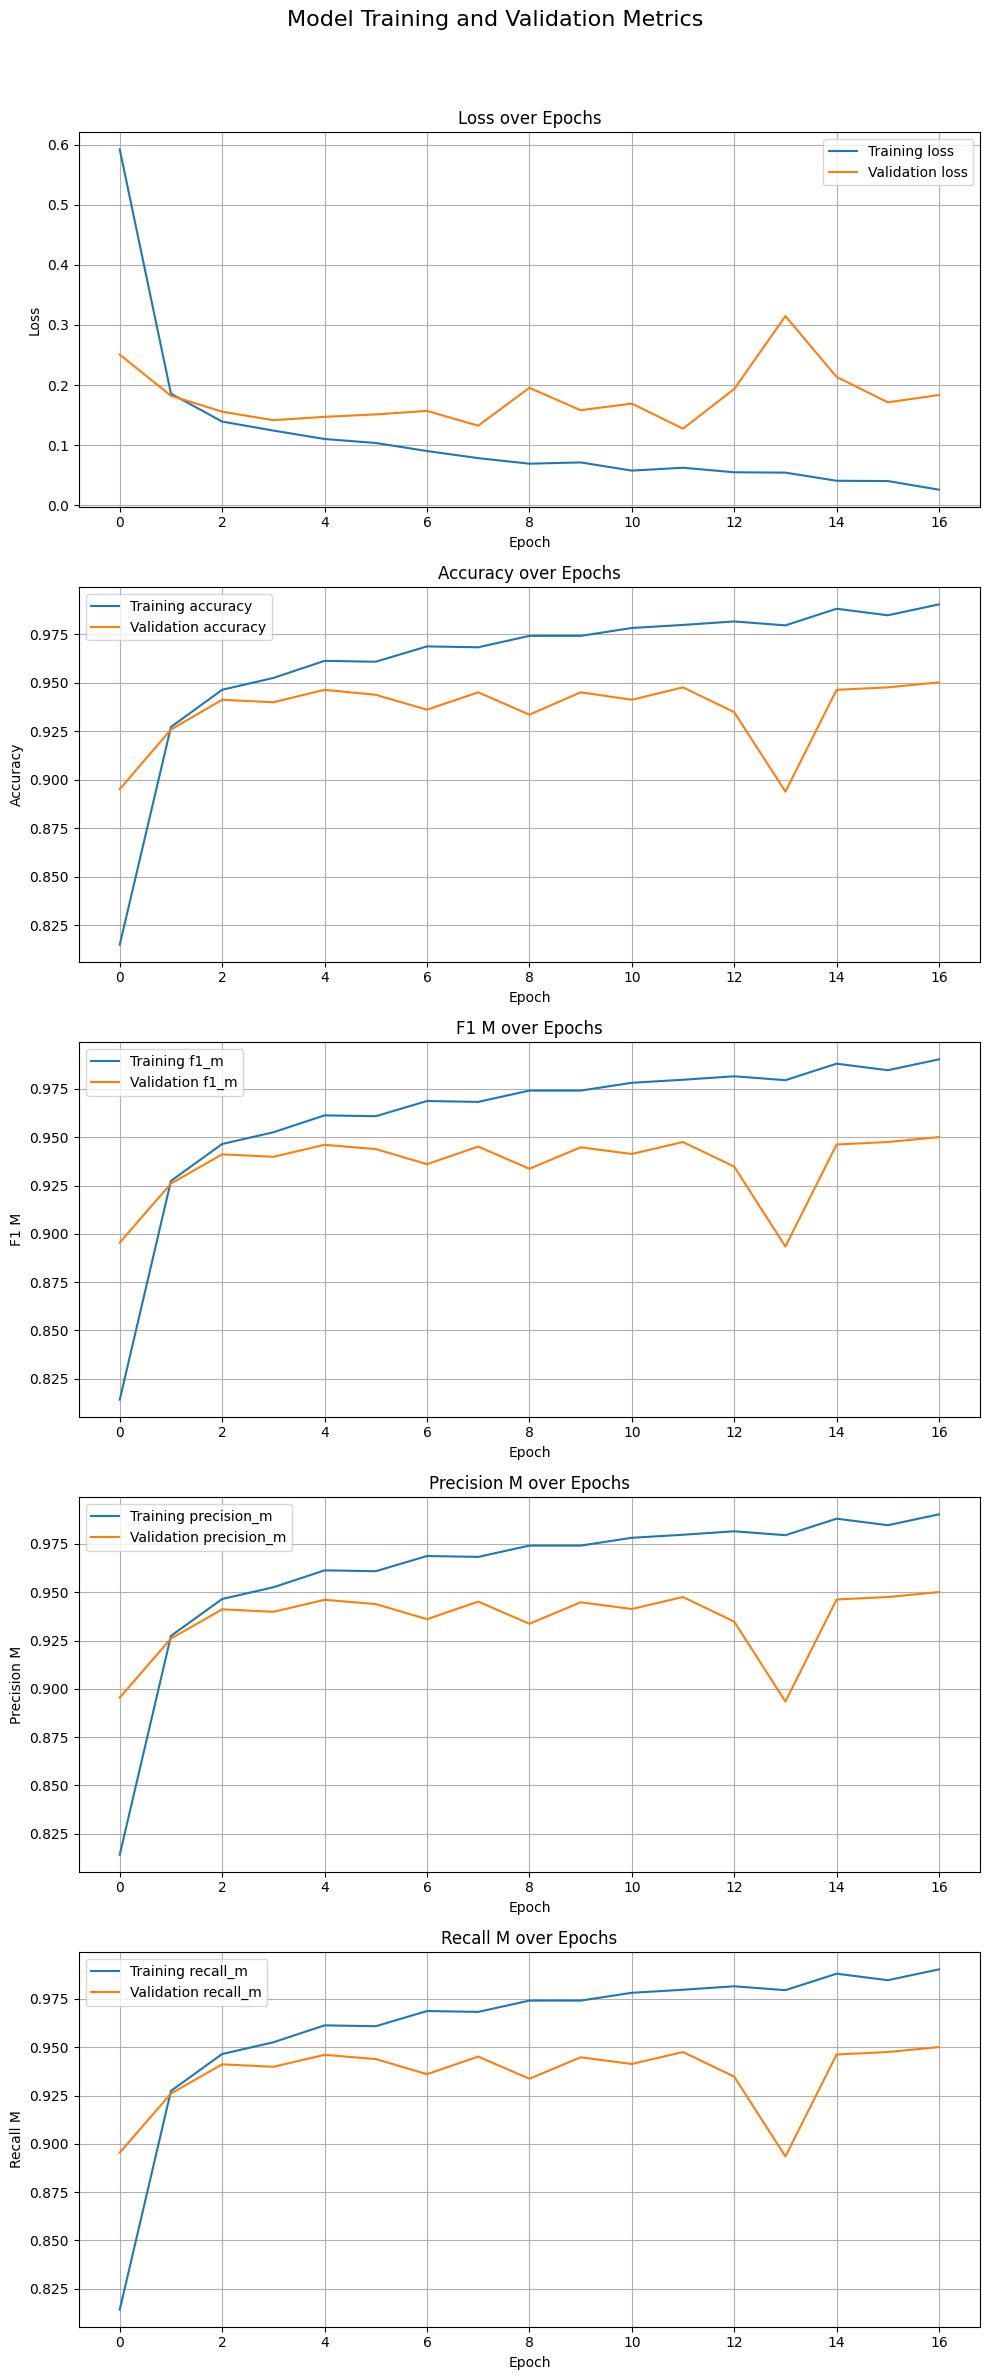

In [46]:
import matplotlib.pyplot as plt

def plot_metrics(history):
    metrics = ['loss', 'accuracy', 'f1_m', 'precision_m', 'recall_m']
    fig, axes = plt.subplots(nrows=len(metrics), ncols=1, figsize=(10, 5 * len(metrics)))
    fig.suptitle('Model Training and Validation Metrics', fontsize=16)

    for i, metric in enumerate(metrics):
        axes[i].plot(history.history[metric], label=f'Training {metric}')
        axes[i].plot(history.history[f'val_{metric}'], label=f'Validation {metric}')
        axes[i].set_title(f'{metric.replace("_", " ").title()} over Epochs')
        axes[i].set_xlabel('Epoch')
        axes[i].set_ylabel(metric.replace("_", " ").title())
        axes[i].legend()
        axes[i].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.show()

plot_metrics(history)